# Q1) Predicting Fraudulent Transactions

A bank monitors credit-card transactions for possible fraud.

For each transaction, let the sample space be

$$
\Omega=\{\omega_1,\omega_2,\omega_3,\omega_4\},
$$

where:

* $\omega_1$: low-risk customer, legitimate transaction,
* $\omega_2$: low-risk customer, fraudulent transaction,
* $\omega_3$: high-risk customer, legitimate transaction,
* $\omega_4$: high-risk customer, fraudulent transaction.

Assume the probabilities are

$$
P(\{\omega_1\})=0.50,\qquad
P(\{\omega_2\})=0.10,\qquad
P(\{\omega_3\})=0.20,\qquad
P(\{\omega_4\})=0.20.
$$

Let $X:\Omega\to\mathbb R$ denote the fraud indicator:

$$
X(\omega_1)=0,\qquad
X(\omega_2)=1,\qquad
X(\omega_3)=0,\qquad
X(\omega_4)=1.
$$

Thus $X=1$ means the transaction is fraudulent, and $X=0$ means it is legitimate.

Now suppose the bank does not observe the full outcome $\omega$, but only the customer's risk class. Define $Y:\Omega\to\mathbb R$ by

$$
Y(\omega_1)=0,\qquad
Y(\omega_2)=0,\qquad
Y(\omega_3)=1,\qquad
Y(\omega_4)=1.
$$

Thus:

* $Y=0$ means “low-risk customer,”
* $Y=1$ means “high-risk customer.”

Answer the following.

1. Write down the probability space $(\Omega,\mathfrak F,P)$, where $\mathfrak F=\mathfrak P(\Omega)$.

2. Compute the $\sigma$-algebra generated by $Y$, namely $\sigma(Y)$.

3. Explain why $E[X\mid Y]$ must be $\sigma(Y)$-measurable, and therefore must be constant on the sets $\{ \omega_1,\omega_2\}$ and $\{\omega_3,\omega_4\}$.

4. Compute $E[X\mid Y]$ explicitly and show that

$$
E[X\mid Y]= \frac{1}{6} \mathbb{1}_{\{Y=0\}} + \frac{1}{2} \mathbb{1}_{\{Y=1\}}
$$

5. Verify the defining property of conditional expectation by checking that for every set $A\in\sigma(Y)$,

$$
\int_A E[X\mid Y]\,dP=\int_A X\,dP.
$$

6. Find the Conditional PMF $p_{X|Y}(x \mid y)$.

7. Verify the identity:
$$
\mathbb{E}[X\mid Y=y] = \sum_{x \in \{0,1\}} x \cdot p_{X|Y}(x \mid y).
$$

8. Calculate the **Mean Square Error (MSE)**

9. How would the **Mean Square Error (MSE)** change if the bank decided to ignore the customer risk class $Y$ and instead used the global average fraud rate ($E[X] = 0.30$) as a constant estimate for every transaction? Calculate this error and explain its relationship to the **Law of Total Variance**.

10. Using the joint distribution of $(X, Y)$ derived from the sample space:

    a) Compute the entropy $H(X)$, representing the bank's initial uncertainty regarding fraud.

    b) Compute the conditional entropy $H(X \mid Y)$, representing the uncertainty remaining after the customer's risk class is revealed.

    c) Calculate the Mutual Information $I(X; Y)$.

    d) Based on these values, what percentage of the total uncertainty about fraud is removed by knowing the customer's risk class?

## Sample Answer

## 1.1 The Probability Space

Each transaction falls into exactly one of four mutually exclusive scenarios, so the sample space has four elements:

$$
\Omega = \{\omega_1, \omega_2, \omega_3, \omega_4\}
$$

| Outcome | Description |
|:---:|:---|
| $\omega_1$ | Low-risk customer, legitimate transaction |
| $\omega_2$ | Low-risk customer, fraudulent transaction |
| $\omega_3$ | High-risk customer, legitimate transaction |
| $\omega_4$ | High-risk customer, fraudulent transaction |

We take $\mathcal{F} = \mathcal{P}(\Omega)$ (the power set — all $2^4 = 16$ subsets). The probability measure assigns:

$$
P(\{\omega_1\}) = 0.50, \quad
P(\{\omega_2\}) = 0.10, \quad
P(\{\omega_3\}) = 0.20, \quad
P(\{\omega_4\}) = 0.20
$$

These sum to $0.50 + 0.10 + 0.20 + 0.20 = 1.00$, confirming this is a valid measure. $\checkmark$

In [ ]:
import numpy as np

probs = {'w1': 0.50, 'w2': 0.10, 'w3': 0.20, 'w4': 0.20}
print('Sum of probabilities:', sum(probs.values()))

# Random variables
X = {'w1': 0, 'w2': 1, 'w3': 0, 'w4': 1}   # fraud indicator
Y = {'w1': 0, 'w2': 0, 'w3': 1, 'w4': 1}   # risk class

## 1.2 The $\sigma$-Algebra Generated by $Y$

The risk indicator $Y$ takes two values. Its pre-images partition $\Omega$:

$$
Y^{-1}(\{0\}) = \{\omega_1, \omega_2\} \quad (\text{low-risk customers})
$$
$$
Y^{-1}(\{1\}) = \{\omega_3, \omega_4\} \quad (\text{high-risk customers})
$$

The smallest $\sigma$-algebra that makes $Y$ measurable must contain these pre-images and be closed under complements and countable unions. The result is:

$$
\sigma(Y) = \bigl\{\varnothing,\; \Omega,\; \{\omega_1, \omega_2\},\; \{\omega_3, \omega_4\}\bigr\}
$$

Intuitively, knowing $Y$ tells you only which risk class a customer belongs to — nothing finer.

## 1.3 Why $E[X \mid Y]$ Must Be Constant on Each Risk Group

By definition, $E[X \mid Y]$ is a $\sigma(Y)$-measurable random variable. This means it can only distinguish events that $Y$ itself can distinguish. Since $\sigma(Y)$ separates $\Omega$ into just two atoms — $\{\omega_1, \omega_2\}$ and $\{\omega_3, \omega_4\}$ — $E[X \mid Y]$ cannot take different values within either atom.

In other words, $E[X \mid Y] = g(Y)$ for some function $g$, and so it must be:

$$
E[X \mid Y](\omega) =
\begin{cases}
a, & \omega \in \{\omega_1, \omega_2\} \\
b, & \omega \in \{\omega_3, \omega_4\}
\end{cases}
$$

for constants $a$ and $b$ to be determined. This is the mathematical expression of a natural fact: the bank can only stratify by risk class, not by individual outcome.

## 1.4 Computing $E[X \mid Y]$ Explicitly

The defining property of conditional expectation requires that for every $A \in \sigma(Y)$:

$$
\int_A E[X \mid Y]\, dP = \int_A X\, dP
$$

**On $A = \{\omega_1, \omega_2\}$ (low-risk group):**

$$
a \cdot P(\{\omega_1, \omega_2\}) = a \cdot 0.60
\quad \text{and} \quad
\int_A X\, dP = 0 \cdot 0.50 + 1 \cdot 0.10 = 0.10
$$

So $0.60a = 0.10 \Rightarrow a = \dfrac{1}{6}$.

**On $A = \{\omega_3, \omega_4\}$ (high-risk group):**

$$
b \cdot P(\{\omega_3, \omega_4\}) = b \cdot 0.40
\quad \text{and} \quad
\int_A X\, dP = 0 \cdot 0.20 + 1 \cdot 0.20 = 0.20
$$

So $0.40b = 0.20 \Rightarrow b = \dfrac{1}{2}$.

Therefore:

$$
E[X \mid Y] = \frac{1}{6}\, \mathbb{1}_{\{Y=0\}} + \frac{1}{2}\, \mathbb{1}_{\{Y=1\}}
$$

In [ ]:
# Marginal probabilities of Y
P_Y0 = probs['w1'] + probs['w2']   # 0.60
P_Y1 = probs['w3'] + probs['w4']   # 0.40

# E[X | Y=0]: fraud rate among low-risk customers
a = (X['w1']*probs['w1'] + X['w2']*probs['w2']) / P_Y0

# E[X | Y=1]: fraud rate among high-risk customers
b = (X['w3']*probs['w3'] + X['w4']*probs['w4']) / P_Y1

print(f'E[X | Y=0]  = {a:.4f}  (= 1/6 = {1/6:.4f})')
print(f'E[X | Y=1]  = {b:.4f}  (= 1/2)')

## 1.5 Verifying the Defining Property

We check all four sets in $\sigma(Y)$:

| $A$ | $\int_A E[X\mid Y]\,dP$ | $\int_A X\,dP$ | Equal? |
|:---|:---:|:---:|:---:|
| $\varnothing$ | $0$ | $0$ | $\checkmark$ |
| $\{\omega_1,\omega_2\}$ | $\frac{1}{6} \times 0.60 = 0.10$ | $0.10$ | $\checkmark$ |
| $\{\omega_3,\omega_4\}$ | $\frac{1}{2} \times 0.40 = 0.20$ | $0.20$ | $\checkmark$ |
| $\Omega$ | $0.10 + 0.20 = 0.30$ | $0.30$ | $\checkmark$ |

The check over $\Omega$ also demonstrates the **Law of Total Expectation**: $E[E[X \mid Y]] = E[X] = 0.30$.

In [ ]:
E_X = sum(X[w]*p for w, p in probs.items())
E_cond = a*P_Y0 + b*P_Y1    # law of total expectation

print(f'E[X]              = {E_X:.4f}')
print(f'E[E[X|Y]]         = {E_cond:.4f}')
print(f'Law of TE holds:    {np.isclose(E_X, E_cond)}')

## 1.6 Conditional PMF $p_{X|Y}(x \mid y)$

Using Bayes' rule for discrete distributions:

$$
p_{X|Y}(x \mid y) = \frac{P(X = x,\, Y = y)}{P(Y = y)}
$$

**Given $Y = 0$ (low-risk):**

$$
p_{X|Y}(0 \mid 0) = \frac{0.50}{0.60} = \frac{5}{6}, \qquad
p_{X|Y}(1 \mid 0) = \frac{0.10}{0.60} = \frac{1}{6}
$$

**Given $Y = 1$ (high-risk):**

$$
p_{X|Y}(0 \mid 1) = \frac{0.20}{0.40} = \frac{1}{2}, \qquad
p_{X|Y}(1 \mid 1) = \frac{0.20}{0.40} = \frac{1}{2}
$$

High-risk customers have a 50% fraud rate — three times that of low-risk customers ($\approx 16.7\%$).

In [ ]:
import pandas as pd

joint = {
    (0,0): probs['w1'], (1,0): probs['w2'],
    (0,1): probs['w3'], (1,1): probs['w4']
}

cond_pmf = {(x,y): joint[(x,y)] / (P_Y0 if y==0 else P_Y1)
            for (x,y) in joint}

df_pmf = pd.DataFrame([
    {'y': y, 'x': x, 'p(X=x|Y=y)': round(v, 4)}
    for (x,y), v in cond_pmf.items()
]).sort_values(['y','x'])
print(df_pmf.to_string(index=False))

## 1.7 Recovering $E[X \mid Y=y]$ from the Conditional PMF

Since $X \in \{0, 1\}$, the conditional expectation equals the conditional fraud probability:

$$
E[X \mid Y=y] = \sum_{x \in \{0,1\}} x \cdot p_{X|Y}(x \mid y) = 0 \cdot p_{X|Y}(0 \mid y) + 1 \cdot p_{X|Y}(1 \mid y)
$$

$$
E[X \mid Y=0] = \frac{1}{6} \qquad E[X \mid Y=1] = \frac{1}{2}
$$

This matches the values derived via the abstract definition in §1.4, as required.

In [ ]:
for y_val, P_Y in [(0, P_Y0), (1, P_Y1)]:
    e = sum(x * cond_pmf[(x, y_val)] for x in [0, 1])
    print(f'E[X | Y={y_val}] = {e:.4f}')

## 1.8 Minimum Mean Square Error (MMSE)

The optimal estimator $E[X \mid Y]$ achieves the lowest possible MSE, which equals the **expected conditional variance**:

$$
\text{MSE}_{\min} = E\bigl[\text{Var}(X \mid Y)\bigr]
$$

Since $X$ is a Bernoulli variable conditional on each $Y$, $\text{Var}(X \mid Y=y) = p(1-p)$:

$$
\text{Var}(X \mid Y=0) = \frac{1}{6} \cdot \frac{5}{6} = \frac{5}{36}
\qquad
\text{Var}(X \mid Y=1) = \frac{1}{2} \cdot \frac{1}{2} = \frac{1}{4}
$$

Averaging over the distribution of $Y$:

$$
E[\text{Var}(X \mid Y)]
= \frac{5}{36} \times 0.60 + \frac{1}{4} \times 0.40
= \frac{1}{12} + \frac{1}{10}
= \frac{11}{60} \approx 0.1833
$$

No estimator that relies only on $Y$ can do better than this.

In [ ]:
var_given_Y0 = a * (1 - a)
var_given_Y1 = b * (1 - b)

MMSE = var_given_Y0 * P_Y0 + var_given_Y1 * P_Y1
print(f'Var(X|Y=0) = {var_given_Y0:.6f}  (= 5/36 = {5/36:.6f})')
print(f'Var(X|Y=1) = {var_given_Y1:.6f}  (= 1/4)')
print(f'MMSE       = {MMSE:.6f}  (= 11/60 = {11/60:.6f})')

## 1.9 Comparing to the Global-Mean Estimator — Law of Total Variance

Suppose the bank ignores risk class entirely and uses the global fraud rate $E[X] = 0.30$ for every transaction. The resulting MSE is simply the total variance of $X$:

$$
\text{MSE}_{\text{global}} = \text{Var}(X) = 0.30 \times 0.70 = 0.21
$$

The **Law of Total Variance** decomposes this into two parts:

$$
\underbrace{\text{Var}(X)}_{\text{Total error}} =
\underbrace{E[\text{Var}(X \mid Y)]}_{\text{Irreducible error}} +
\underbrace{\text{Var}(E[X \mid Y])}_{\text{Reduction from using }Y}
$$

The second term — the variance of the estimator itself — quantifies how much knowing $Y$ helps:

$$
\text{Var}(E[X \mid Y]) = 0.21 - \frac{11}{60} = \frac{12.6 - 11}{60} = \frac{1.6}{60} \approx 0.0267
$$

So using the risk class reduces the prediction error from **0.21** to **0.1833**, a saving of about **12.7%**.

In [ ]:
Var_X   = E_X * (1 - E_X)
Var_EXY = Var_X - MMSE            # explained variance

print(f'Var(X)             = {Var_X:.4f}  (global MSE)')
print(f'E[Var(X|Y)]        = {MMSE:.4f}  (irreducible MMSE)')
print(f'Var(E[X|Y])        = {Var_EXY:.4f}  (reduction from Y)')
print(f'LTV check (sum):   = {MMSE + Var_EXY:.4f}  (should = Var(X))')
print(f'Error reduction:   = {Var_EXY / Var_X * 100:.1f}%')

## 1.10 Information Theory: Entropy and Mutual Information

### Joint Distribution Summary

| | $Y=0$ | $Y=1$ | $P(X=x)$ |
|:---:|:---:|:---:|:---:|
| $X=0$ | 0.50 | 0.20 | 0.70 |
| $X=1$ | 0.10 | 0.20 | 0.30 |
| $P(Y=y)$ | 0.60 | 0.40 | 1.00 |

### (a) Marginal Entropy $H(X)$

This measures the bank's uncertainty about fraud before observing anything:

$$
H(X) = -\bigl(0.70 \log_2 0.70 + 0.30 \log_2 0.30\bigr) \approx 0.881 \text{ bits}
$$

### (b) Conditional Entropy $H(X \mid Y)$

This is the uncertainty that remains after the risk class is disclosed:

$$
H(X \mid Y=0) = -\left[\tfrac{1}{6}\log_2\tfrac{1}{6} + \tfrac{5}{6}\log_2\tfrac{5}{6}\right] \approx 0.650 \text{ bits}
$$

$$
H(X \mid Y=1) = -\left[\tfrac{1}{2}\log_2\tfrac{1}{2} + \tfrac{1}{2}\log_2\tfrac{1}{2}\right] = 1.000 \text{ bit}
$$

$$
H(X \mid Y) = 0.60 \times 0.650 + 0.40 \times 1.000 = 0.390 + 0.400 = 0.790 \text{ bits}
$$

Interestingly, high-risk customers ($Y=1$) are maximally uncertain — the fraud probability is exactly 50%.

### (c) Mutual Information $I(X; Y)$

$$
I(X; Y) = H(X) - H(X \mid Y) \approx 0.881 - 0.790 = 0.091 \text{ bits}
$$

### (d) Fraction of Uncertainty Removed

$$
\frac{I(X; Y)}{H(X)} = \frac{0.091}{0.881} \approx 10.3\%
$$

Knowing the risk class resolves just over 10% of the total uncertainty about fraud. The risk label is informative but far from sufficient for reliable fraud detection on its own.

In [ ]:
import matplotlib.pyplot as plt

def entropy(ps):
    ps = np.array(ps)
    ps = ps[ps > 0]
    return -np.sum(ps * np.log2(ps))

H_X    = entropy([0.70, 0.30])
H_XY0  = entropy([5/6, 1/6])
H_XY1  = entropy([0.5, 0.5])
H_XgY  = P_Y0 * H_XY0 + P_Y1 * H_XY1
MI     = H_X - H_XgY

print(f'H(X)         = {H_X:.4f} bits')
print(f'H(X|Y=0)     = {H_XY0:.4f} bits')
print(f'H(X|Y=1)     = {H_XY1:.4f} bits')
print(f'H(X|Y)       = {H_XgY:.4f} bits')
print(f'I(X; Y)      = {MI:.4f} bits')
print(f'Uncertainty removed: {MI/H_X*100:.1f}%')

# --- Visual summary ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart: entropy decomposition
ax = axes[0]
bars = ax.bar(['H(X)\n(total)', 'H(X|Y)\n(remaining)', 'I(X;Y)\n(gain)'],
              [H_X, H_XgY, MI],
              color=['#185FA5', '#D85A30', '#3B6D11'], alpha=0.85)
ax.set_ylabel('Entropy (bits)')
ax.set_title('Information-Theoretic Decomposition')
for bar, val in zip(bars, [H_X, H_XgY, MI]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
            f'{val:.3f}', ha='center', fontsize=10)
ax.set_ylim(0, 1.05)

# Bar chart: variance decomposition
ax2 = axes[1]
bars2 = ax2.bar(
    ['Var(X)\n(total MSE)', 'E[Var(X|Y)]\n(MMSE)', 'Var(E[X|Y])\n(reduction)'],
    [Var_X, MMSE, Var_EXY],
    color=['#185FA5', '#D85A30', '#3B6D11'], alpha=0.85
)
ax2.set_ylabel('Variance')
ax2.set_title('Law of Total Variance Decomposition')
for bar, val in zip(bars2, [Var_X, MMSE, Var_EXY]):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.001,
             f'{val:.4f}', ha='center', fontsize=10)
ax2.set_ylim(0, 0.25)

plt.tight_layout()
plt.show()

# Q2) Conditional Density of the Multivariate Gaussian

Let $\mathbf{Z}$ be the concatenated random matrix
$\mathbf{Z} = \begin{bmatrix} \mathbf{X} \\ \mathbf{Y} \end{bmatrix} \in \mathbb{R}^{n+m}$.


The random variable $\mathbf{Z}$ is said to have a **joint multivariate normal distribution** if every linear combination of its components follows a univariate normal distribution.

For $\mathbf{Z}$ to possess a **joint density function** (meaning its distribution is absolutely continuous with respect to the Lebesgue measure on $\mathbb{R}^{n+m}$), its covariance matrix must be non-singular (positive definite).


The joint density function $f_{\mathbf{X}, \mathbf{Y}}(\mathbf{z})$ for $\mathbf{z} \in \mathbb{R}^{n+m}$ is given by:

$$f_{\mathbf{X}, \mathbf{Y}}(\mathbf{z}) = \frac{1}{\sqrt{(2\pi)^{n+m} |\boldsymbol{\Sigma}|}} \exp\left( -\frac{1}{2} (\mathbf{z} - \boldsymbol{\mu})^T \boldsymbol{\Sigma}^{-1} (\mathbf{z} - \boldsymbol{\mu}) \right).$$

Here:

* **Mean ($\boldsymbol{\mu}$):** $\boldsymbol{\mu} = E[\mathbf{Z}] = \begin{bmatrix} \boldsymbol{\mu}_X \\ \boldsymbol{\mu}_Y \end{bmatrix} \in \mathbb{R}^{n+m}$, where $\boldsymbol{\mu}_X \in \mathbb{R}^n$ and $\boldsymbol{\mu}_Y \in \mathbb{R}^m$.
* **Covariance Matrix ($\boldsymbol{\Sigma}$):** A symmetric, positive definite matrix $\boldsymbol{\Sigma} \in \mathbb{R}^{(n+m) \times (n+m)}$ partitioned as:
$$\boldsymbol{\Sigma} = \begin{bmatrix} \boldsymbol{\Sigma}_{XX} & \boldsymbol{\Sigma}_{XY} \\ \boldsymbol{\Sigma}_{YX} & \boldsymbol{\Sigma}_{YY} \end{bmatrix}$$
    * $\boldsymbol{\Sigma}_{XX} = \text{Var}(\mathbf{X})$ (size $n \times n$)
    * $\boldsymbol{\Sigma}_{YY} = \text{Var}(\mathbf{Y})$ (size $m \times m$)
    * $\boldsymbol{\Sigma}_{XY} = \text{Cov}(\mathbf{X}, \mathbf{Y}) = \boldsymbol{\Sigma}_{YX}^T$ (size $n \times m$)
* **Determinant ($|\boldsymbol{\Sigma}|$):** The normalization factor ensuring the total integral is 1.

Show that the conditional distribution is given by $f_{\mathbf{X}|\mathbf{Y}}(\mathbf{x} \mid \mathbf{y})$

$$f_{\mathbf{X}|\mathbf{Y}}(\mathbf{x} \mid \mathbf{y}) = \frac{1}{\sqrt{(2\pi)^n |\mathbf{S}_{XX}|}} \exp\left( -\frac{1}{2} (\mathbf{x} - \boldsymbol{\mu}^*)^T \boldsymbol{\Sigma}_{X\mid Y}^{-1} (\mathbf{x} - \boldsymbol{\mu}^*) \right),$$
where
* $\boldsymbol{\Sigma}_{X\mid Y} = \boldsymbol{\Sigma}_{XX} - \boldsymbol{\Sigma}_{XY}\boldsymbol{\Sigma}_{YY}^{-1}\boldsymbol{\Sigma}_{YX}$
* $\boldsymbol{\mu}^* = \boldsymbol{\mu}_x + \boldsymbol{\Sigma}_{XY}\boldsymbol{\Sigma}_{YY}^{-1}(\mathbf{y} - \boldsymbol{\mu}_y)$

## Sample Answer

## 1. Setup and Joint Density

Let $\mathbf{Z} = \begin{bmatrix} \mathbf{X} \\ \mathbf{Y} \end{bmatrix} \in \mathbb{R}^{n+m}$ be jointly multivariate Gaussian — meaning every linear combination of its components is univariate normal. For the distribution to have a density (absolute continuity with respect to Lebesgue measure), the covariance matrix must be positive definite (non-singular).

The joint density is:

$$
f_{\mathbf{X},\mathbf{Y}}(\mathbf{z})
= \frac{1}{\sqrt{(2\pi)^{n+m} |\boldsymbol{\Sigma}|}}
\exp\!\left(-\frac{1}{2}(\mathbf{z} - \boldsymbol{\mu})^T \boldsymbol{\Sigma}^{-1} (\mathbf{z} - \boldsymbol{\mu})\right)
$$

with partitioned mean and covariance:

$$
\boldsymbol{\mu} = \begin{bmatrix} \boldsymbol{\mu}_X \\ \boldsymbol{\mu}_Y \end{bmatrix},
\qquad
\boldsymbol{\Sigma} = \begin{bmatrix} \boldsymbol{\Sigma}_{XX} & \boldsymbol{\Sigma}_{XY} \\ \boldsymbol{\Sigma}_{YX} & \boldsymbol{\Sigma}_{YY} \end{bmatrix}
$$

where $\boldsymbol{\Sigma}_{XY} = \boldsymbol{\Sigma}_{YX}^T$.

## 2. Marginal Distributions

### Key Tool: Block Matrix Inversion via Schur Complement

The joint quadratic form $Q = (\mathbf{z} - \boldsymbol{\mu})^T \boldsymbol{\Sigma}^{-1} (\mathbf{z} - \boldsymbol{\mu})$ mixes $\mathbf{x}$ and $\mathbf{y}$, making direct integration difficult. The Schur complement lets us factor $\boldsymbol{\Sigma}^{-1}$ into a product that separates the two variables.

### 2.1 Marginal Density of $\mathbf{X}$

We use the **Schur complement of $\boldsymbol{\Sigma}_{XX}$**:

$$
\mathbf{S}_{YY} = \boldsymbol{\Sigma}_{YY} - \boldsymbol{\Sigma}_{YX}\boldsymbol{\Sigma}_{XX}^{-1}\boldsymbol{\Sigma}_{XY}
$$

Setting $\tilde{\mathbf{x}} = \mathbf{x} - \boldsymbol{\mu}_X$ and $\tilde{\mathbf{y}} = \mathbf{y} - \boldsymbol{\mu}_Y$, the quadratic form factors as:

$$
Q = \tilde{\mathbf{x}}^T \boldsymbol{\Sigma}_{XX}^{-1} \tilde{\mathbf{x}}
+ (\tilde{\mathbf{y}} - \mathbf{A}\tilde{\mathbf{x}})^T \mathbf{S}_{YY}^{-1} (\tilde{\mathbf{y}} - \mathbf{A}\tilde{\mathbf{x}}),
\qquad \mathbf{A} = \boldsymbol{\Sigma}_{YX}\boldsymbol{\Sigma}_{XX}^{-1}
$$

The joint density then factors into two pieces:

$$
f_{\mathbf{X},\mathbf{Y}} \propto
\underbrace{\exp\!\left(-\tfrac{1}{2}\tilde{\mathbf{x}}^T \boldsymbol{\Sigma}_{XX}^{-1}\tilde{\mathbf{x}}\right)}_{\text{depends only on }\mathbf{x}}
\cdot
\underbrace{\exp\!\left(-\tfrac{1}{2}(\tilde{\mathbf{y}} - \mathbf{A}\tilde{\mathbf{x}})^T \mathbf{S}_{YY}^{-1} (\tilde{\mathbf{y}} - \mathbf{A}\tilde{\mathbf{x}})\right)}_{\text{Gaussian in }\mathbf{y}\text{ given }\mathbf{x}}
$$

Integrating over $\mathbf{y} \in \mathbb{R}^m$: the second factor integrates to $\sqrt{(2\pi)^m |\mathbf{S}_{YY}|}$ (the normalising constant of a Gaussian in $\mathbf{y}$). Using the block determinant identity $|\boldsymbol{\Sigma}| = |\boldsymbol{\Sigma}_{XX}| \cdot |\mathbf{S}_{YY}|$, all constants simplify to yield:

$$
\boxed{f_{\mathbf{X}}(\mathbf{x}) = \frac{1}{\sqrt{(2\pi)^n |\boldsymbol{\Sigma}_{XX}|}}
\exp\!\left(-\frac{1}{2}(\mathbf{x} - \boldsymbol{\mu}_X)^T \boldsymbol{\Sigma}_{XX}^{-1} (\mathbf{x} - \boldsymbol{\mu}_X)\right)}
$$

So $\mathbf{X} \sim \mathcal{N}(\boldsymbol{\mu}_X, \boldsymbol{\Sigma}_{XX})$.

### 2.2 Marginal Density of $\mathbf{Y}$

By symmetry, we instead use the **Schur complement of $\boldsymbol{\Sigma}_{YY}$**:

$$
\mathbf{S}_{XX} = \boldsymbol{\Sigma}_{XX} - \boldsymbol{\Sigma}_{XY}\boldsymbol{\Sigma}_{YY}^{-1}\boldsymbol{\Sigma}_{YX}
$$

This factors $Q$ so that the $\mathbf{x}$-dependent piece is a Gaussian in $\mathbf{x}$ given $\mathbf{y}$. Integrating over $\mathbf{x}$ and cancelling constants via $|\boldsymbol{\Sigma}| = |\boldsymbol{\Sigma}_{YY}| \cdot |\mathbf{S}_{XX}|$:

$$
\boxed{f_{\mathbf{Y}}(\mathbf{y}) = \frac{1}{\sqrt{(2\pi)^m |\boldsymbol{\Sigma}_{YY}|}}
\exp\!\left(-\frac{1}{2}(\mathbf{y} - \boldsymbol{\mu}_Y)^T \boldsymbol{\Sigma}_{YY}^{-1} (\mathbf{y} - \boldsymbol{\mu}_Y)\right)}
$$

So $\mathbf{Y} \sim \mathcal{N}(\boldsymbol{\mu}_Y, \boldsymbol{\Sigma}_{YY})$. Both marginals are also Gaussian — the multivariate Gaussian is closed under marginalisation.

## 3. Conditional Density

We apply the definition of conditional density:

$$
f_{\mathbf{X}|\mathbf{Y}}(\mathbf{x} \mid \mathbf{y})
= \frac{f_{\mathbf{X},\mathbf{Y}}(\mathbf{x}, \mathbf{y})}{f_{\mathbf{Y}}(\mathbf{y})}
$$

**In the exponent**, dividing is equivalent to subtracting quadratic forms ($e^A / e^B = e^{A-B}$). From §2.2, using the Schur complement of $\boldsymbol{\Sigma}_{YY}$:

$$
Q_{\text{joint}} = \underbrace{(\mathbf{y} - \boldsymbol{\mu}_Y)^T \boldsymbol{\Sigma}_{YY}^{-1} (\mathbf{y} - \boldsymbol{\mu}_Y)}_{Q_{\text{marginal}}} + (\mathbf{x} - \boldsymbol{\mu}^*)^T \mathbf{S}_{XX}^{-1} (\mathbf{x} - \boldsymbol{\mu}^*)
$$

where the conditional mean is:

$$
\boldsymbol{\mu}^* = \boldsymbol{\mu}_X + \boldsymbol{\Sigma}_{XY}\boldsymbol{\Sigma}_{YY}^{-1}(\mathbf{y} - \boldsymbol{\mu}_Y)
$$

Subtracting $Q_{\text{marginal}}$ leaves only the $\mathbf{x}$-dependent piece. **For the constants**, dividing the joint prefactor by the marginal prefactor and applying $|\boldsymbol{\Sigma}| = |\boldsymbol{\Sigma}_{YY}| \cdot |\mathbf{S}_{XX}|$ gives exactly $1/\sqrt{(2\pi)^n |\mathbf{S}_{XX}|}$.

Combining:

$$
\boxed{f_{\mathbf{X}|\mathbf{Y}}(\mathbf{x} \mid \mathbf{y})
= \frac{1}{\sqrt{(2\pi)^n |\mathbf{S}_{XX}|}}
\exp\!\left(-\frac{1}{2}(\mathbf{x} - \boldsymbol{\mu}^*)^T \mathbf{S}_{XX}^{-1} (\mathbf{x} - \boldsymbol{\mu}^*)\right)}
$$

This is the density of $\mathcal{N}(\boldsymbol{\mu}^*, \mathbf{S}_{XX})$, so:

$$
(\mathbf{X} \mid \mathbf{Y} = \mathbf{y})
\sim \mathcal{N}\bigl(
\boldsymbol{\mu}_X + \boldsymbol{\Sigma}_{XY}\boldsymbol{\Sigma}_{YY}^{-1}(\mathbf{y} - \boldsymbol{\mu}_Y),\;
\boldsymbol{\Sigma}_{XX} - \boldsymbol{\Sigma}_{XY}\boldsymbol{\Sigma}_{YY}^{-1}\boldsymbol{\Sigma}_{YX}
\bigr)
$$

### Summary of Parameters

| Parameter | Formula | Interpretation |
|:---|:---|:---|
| Conditional mean $\boldsymbol{\mu}^*$ | $\boldsymbol{\mu}_X + \boldsymbol{\Sigma}_{XY}\boldsymbol{\Sigma}_{YY}^{-1}(\mathbf{y} - \boldsymbol{\mu}_Y)$ | Prior mean adjusted by observed deviation of $\mathbf{Y}$, scaled by the regression coefficient |
| Conditional covariance $\boldsymbol{\Sigma}_{X\mid Y}$ | $\boldsymbol{\Sigma}_{XX} - \boldsymbol{\Sigma}_{XY}\boldsymbol{\Sigma}_{YY}^{-1}\boldsymbol{\Sigma}_{YX}$ | Always smaller than $\boldsymbol{\Sigma}_{XX}$; **does not depend on the observed value $\mathbf{y}$** |

## 4. Conditional Expectation

By the Disintegration Theorem, $E[\mathbf{X} \mid \mathbf{Y} = \mathbf{y}]$ is the first moment of the conditional distribution:

$$
E[\mathbf{X} \mid \mathbf{Y} = \mathbf{y}]
= \int_{\mathbb{R}^n} \mathbf{x}\, f_{\mathbf{X}|\mathbf{Y}}(\mathbf{x} \mid \mathbf{y})\, d\mathbf{x}
= \boldsymbol{\mu}^*
= \boldsymbol{\mu}_X + \boldsymbol{\Sigma}_{XY}\boldsymbol{\Sigma}_{YY}^{-1}(\mathbf{y} - \boldsymbol{\mu}_Y)
$$

As a random variable (treating $\mathbf{Y}$ as random):

$$
E[\mathbf{X} \mid \mathbf{Y}] = \boldsymbol{\mu}_X + \boldsymbol{\Sigma}_{XY}\boldsymbol{\Sigma}_{YY}^{-1}(\mathbf{Y} - \boldsymbol{\mu}_Y)
$$

This is a **linear function of $\mathbf{Y}$** — a consequence unique to the Gaussian family. For any other joint distribution, the conditional expectation would generally be non-linear.

## 5. Variance Decomposition via the Law of Total Variance

The conditional covariance is constant across all values of $\mathbf{y}$, so:

$$
\mathrm{Var}(\mathbf{X} \mid \mathbf{Y}) = \boldsymbol{\Sigma}_{XX} - \boldsymbol{\Sigma}_{XY}\boldsymbol{\Sigma}_{YY}^{-1}\boldsymbol{\Sigma}_{YX}
\qquad (\text{deterministic — no randomness in }\mathbf{Y})
$$

The Law of Total Variance states $\mathrm{Var}(\mathbf{X}) = E[\mathrm{Var}(\mathbf{X}\mid\mathbf{Y})] + \mathrm{Var}(E[\mathbf{X}\mid\mathbf{Y}])$. Since the conditional variance is constant, $E[\mathrm{Var}(\mathbf{X}\mid\mathbf{Y})] = \mathrm{Var}(\mathbf{X}\mid\mathbf{Y})$, and therefore:

$$
\underbrace{\boldsymbol{\Sigma}_{XX}}_{\mathrm{Var}(\mathbf{X})}
= \underbrace{\boldsymbol{\Sigma}_{XX} - \boldsymbol{\Sigma}_{XY}\boldsymbol{\Sigma}_{YY}^{-1}\boldsymbol{\Sigma}_{YX}}_{\text{unexplained variance (MMSE)}}
+ \underbrace{\boldsymbol{\Sigma}_{XY}\boldsymbol{\Sigma}_{YY}^{-1}\boldsymbol{\Sigma}_{YX}}_{\text{explained variance (information from }\mathbf{Y}\text{)}}
$$

The MMSE of the best estimator is:

$$
E\bigl[(\mathbf{X} - E[\mathbf{X}\mid\mathbf{Y}])^2\bigr]
= \boldsymbol{\Sigma}_{XX} - \boldsymbol{\Sigma}_{XY}\boldsymbol{\Sigma}_{YY}^{-1}\boldsymbol{\Sigma}_{YX}
$$

## 6. Differential Entropy and Mutual Information

### 6.1 Entropy of a Multivariate Gaussian

For $\mathbf{Z} \sim \mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$ with dimension $d = n+m$:

$$
h(\mathbf{Z}) = -E[\ln f(\mathbf{Z})]
$$

Taking the log of the density and applying the expectation:

$$
h(\mathbf{Z}) = \frac{1}{2}\ln((2\pi)^d |\boldsymbol{\Sigma}|) + \frac{1}{2}E\bigl[(\mathbf{Z}-\boldsymbol{\mu})^T\boldsymbol{\Sigma}^{-1}(\mathbf{Z}-\boldsymbol{\mu})\bigr]
$$

The quadratic form expectation equals $\mathrm{Tr}(\boldsymbol{\Sigma}^{-1}\boldsymbol{\Sigma}) = \mathrm{Tr}(\mathbf{I}_d) = d$, so:

$$
h(\mathbf{Z}) = \frac{1}{2}\ln\bigl((2\pi e)^d |\boldsymbol{\Sigma}|\bigr)
$$

### 6.2 Conditional Entropy

Since the conditional distribution $(\mathbf{X} \mid \mathbf{Y}=\mathbf{y})$ is Gaussian with constant covariance $\boldsymbol{\Sigma}_{X|Y}$ (independent of $\mathbf{y}$), the conditional entropy is:

$$
h(\mathbf{X} \mid \mathbf{Y}) = \frac{1}{2}\ln\bigl((2\pi e)^n |\boldsymbol{\Sigma}_{X|Y}|\bigr),
\qquad \boldsymbol{\Sigma}_{X|Y} = \boldsymbol{\Sigma}_{XX} - \boldsymbol{\Sigma}_{XY}\boldsymbol{\Sigma}_{YY}^{-1}\boldsymbol{\Sigma}_{YX}
$$

### 6.3 Mutual Information

$$
I(\mathbf{X}; \mathbf{Y}) = h(\mathbf{X}) - h(\mathbf{X} \mid \mathbf{Y})
= \frac{1}{2}\ln\frac{|\boldsymbol{\Sigma}_{XX}|}{|\boldsymbol{\Sigma}_{X|Y}|}
= \frac{1}{2}\ln\frac{|\boldsymbol{\Sigma}_{XX}|}{|\boldsymbol{\Sigma}_{XX} - \boldsymbol{\Sigma}_{XY}\boldsymbol{\Sigma}_{YY}^{-1}\boldsymbol{\Sigma}_{YX}|}
$$

For the univariate case ($n = m = 1$) with correlation $\rho = \Sigma_{XY}/\sqrt{\Sigma_{XX}\Sigma_{YY}}$:

$$
I(X; Y) = -\frac{1}{2}\ln(1 - \rho^2)
$$

which is zero when $\rho = 0$ (independence) and grows without bound as $|\rho| \to 1$ (perfect linear dependence).

## 7. Numerical Demonstration

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)

# --- Parameters ---
mu    = np.array([0.0, 0.0])
Sigma = np.array([[1.0, 0.7],
                  [0.7, 1.0]])

Sigma_XX = Sigma[0, 0]
Sigma_YY = Sigma[1, 1]
Sigma_XY = Sigma[0, 1]

# --- Conditional distribution given Y = y_obs ---
y_obs   = 1.2
mu_cond = mu[0] + (Sigma_XY / Sigma_YY) * (y_obs - mu[1])
var_cond = Sigma_XX - (Sigma_XY**2 / Sigma_YY)

print('Conditional distribution P(X | Y = 1.2):')
print(f'  mu*   = {mu_cond:.4f}  (vs marginal mean = {mu[0]})')
print(f'  var*  = {var_cond:.4f}  (vs marginal var  = {Sigma_XX})')

# --- Samples ---
n_samples = 6000
data = np.random.multivariate_normal(mu, Sigma, n_samples)
x_s, y_s = data[:, 0], data[:, 1]

# Filter for Y ≈ y_obs
mask   = np.abs(y_s - y_obs) < 0.15
x_cond = x_s[mask]
print(f'\nEmpirical (from {mask.sum()} samples with |Y - {y_obs}| < 0.15):')
print(f'  empirical mean  = {x_cond.mean():.4f}')
print(f'  empirical var   = {x_cond.var():.4f}')

Conditional distribution P(X | Y = 1.2):
  mu*   = 0.8400  (vs marginal mean = 0.0)
  var*  = 0.5100  (vs marginal var  = 1.0)

Empirical (from 344 samples with |Y - 1.2| < 0.15):
  empirical mean  = 0.8388
  empirical var   = 0.5202


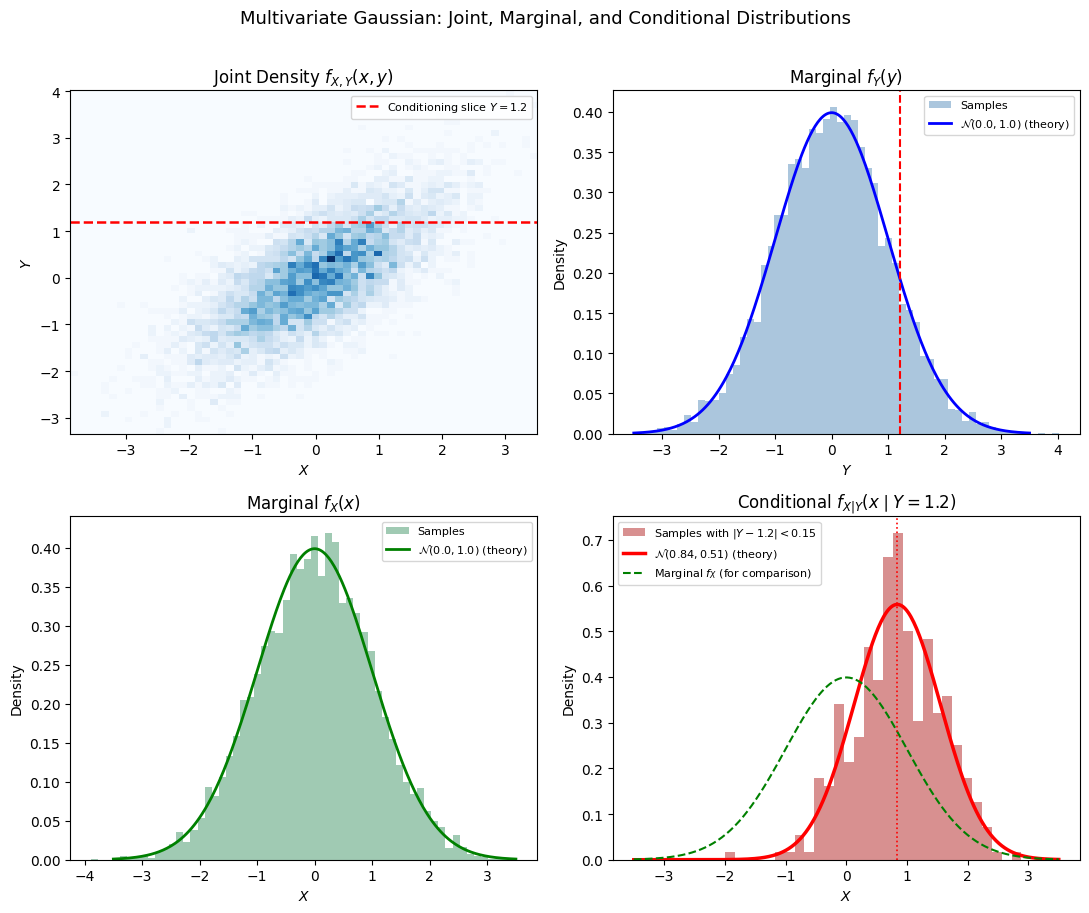

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
fig.suptitle('Multivariate Gaussian: Joint, Marginal, and Conditional Distributions',
             fontsize=13, y=1.01)

# ── (0,0) Joint density as 2-D histogram ──────────────────────────────────
ax = axes[0, 0]
ax.hist2d(x_s, y_s, bins=60, cmap='Blues')
ax.axhline(y_obs, color='red', lw=1.8, linestyle='--',
           label=f'Conditioning slice $Y={y_obs}$')
ax.set_xlabel('$X$'); ax.set_ylabel('$Y$')
ax.set_title('Joint Density $f_{X,Y}(x, y)$')
ax.legend(fontsize=8)

# ── (0,1) Marginal of Y ───────────────────────────────────────────────────
ax = axes[0, 1]
y_grid = np.linspace(-3.5, 3.5, 300)
ax.hist(y_s, bins=60, density=True, alpha=0.45, color='steelblue',
        label='Samples')
ax.plot(y_grid, norm.pdf(y_grid, mu[1], np.sqrt(Sigma_YY)), 'b-', lw=2,
        label=f'$\\mathcal{{N}}({mu[1]}, {Sigma_YY})$ (theory)')
ax.axvline(y_obs, color='red', lw=1.5, linestyle='--')
ax.set_xlabel('$Y$'); ax.set_ylabel('Density')
ax.set_title('Marginal $f_Y(y)$')
ax.legend(fontsize=8)

# ── (1,0) Marginal of X ───────────────────────────────────────────────────
ax = axes[1, 0]
x_grid = np.linspace(-3.5, 3.5, 300)
ax.hist(x_s, bins=60, density=True, alpha=0.45, color='seagreen',
        label='Samples')
ax.plot(x_grid, norm.pdf(x_grid, mu[0], np.sqrt(Sigma_XX)), 'g-', lw=2,
        label=f'$\\mathcal{{N}}({mu[0]}, {Sigma_XX})$ (theory)')
ax.set_xlabel('$X$'); ax.set_ylabel('Density')
ax.set_title('Marginal $f_X(x)$')
ax.legend(fontsize=8)

# ── (1,1) Conditional X | Y = y_obs ─────────────────────────────────────
ax = axes[1, 1]
ax.hist(x_cond, bins=30, density=True, alpha=0.5, color='firebrick',
        label=f'Samples with $|Y - {y_obs}| < 0.15$')
ax.plot(x_grid, norm.pdf(x_grid, mu_cond, np.sqrt(var_cond)), 'r-', lw=2.5,
        label=f'$\\mathcal{{N}}({mu_cond:.2f}, {var_cond:.2f})$ (theory)')
ax.plot(x_grid, norm.pdf(x_grid, mu[0], np.sqrt(Sigma_XX)), 'g--', lw=1.5,
        label='Marginal $f_X$ (for comparison)')
ax.axvline(mu_cond, color='red', lw=1.2, linestyle=':')
ax.set_xlabel('$X$'); ax.set_ylabel('Density')
ax.set_title(f'Conditional $f_{{X|Y}}(x \\mid Y={y_obs})$')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

Information-theoretic summary:
  Correlation ρ        = 0.70
  h(X)                 = 1.4189 nats
  h(X | Y)             = 1.0823 nats
  I(X; Y)              = 0.3367 nats
  Variance reduction   = 49.0%
  Cross-check via rho: = 0.3367 nats


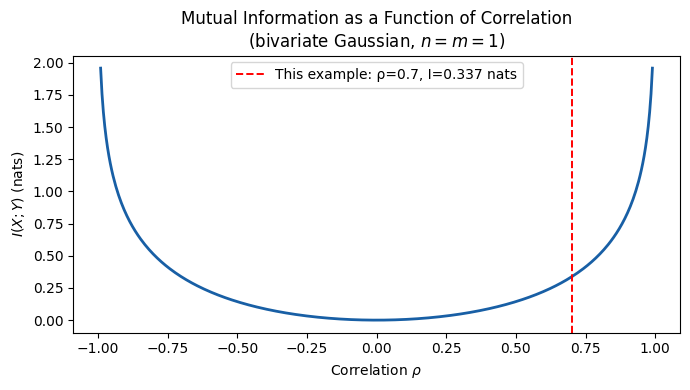

In [3]:
# --- Information-theoretic quantities ---
rho  = Sigma_XY / np.sqrt(Sigma_XX * Sigma_YY)
h_X  = 0.5 * np.log(2 * np.pi * np.e * Sigma_XX)
h_XgY = 0.5 * np.log(2 * np.pi * np.e * var_cond)
MI   = h_X - h_XgY          # = -0.5 * log(1 - rho^2)
pct  = (1 - var_cond / Sigma_XX) * 100

print('Information-theoretic summary:')
print(f'  Correlation ρ        = {rho:.2f}')
print(f'  h(X)                 = {h_X:.4f} nats')
print(f'  h(X | Y)             = {h_XgY:.4f} nats')
print(f'  I(X; Y)              = {MI:.4f} nats')
print(f'  Variance reduction   = {pct:.1f}%')
print(f'  Cross-check via rho: = {-0.5*np.log(1-rho**2):.4f} nats')

# --- How MI varies with correlation ---
rhos = np.linspace(-0.99, 0.99, 400)
MIs  = -0.5 * np.log(1 - rhos**2)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(rhos, MIs, color='#185FA5', lw=2)
ax.axvline(rho, color='red', lw=1.4, linestyle='--',
           label=f'This example: ρ={rho:.1f}, I={MI:.3f} nats')
ax.set_xlabel('Correlation $\\rho$')
ax.set_ylabel('$I(X; Y)$ (nats)')
ax.set_title('Mutual Information as a Function of Correlation\n(bivariate Gaussian, $n=m=1$)')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Observations from the Visualisations

**Joint plot:** The tilted elliptical cloud reflects the positive correlation $\Sigma_{XY} = 0.7$. The red dashed line marks the conditioning slice $Y = 1.2$.

**Marginal plots:** Both marginals are symmetric Gaussian bells centred at zero, as predicted by $\mathbf{X} \sim \mathcal{N}(\boldsymbol{\mu}_X, \boldsymbol{\Sigma}_{XX})$ and $\mathbf{Y} \sim \mathcal{N}(\boldsymbol{\mu}_Y, \boldsymbol{\Sigma}_{YY})$.

**Conditional plot:** Two effects are visible compared to the marginal:
- The conditional mean $\mu^* \approx 0.84$ is shifted rightward from 0. Because $X$ and $Y$ are positively correlated, a high $Y$ observation ($1.2$) makes high $X$ more likely.
- The conditional distribution is *narrower* (variance $\approx 0.51$) than the marginal (variance $1.0$). Observing $Y$ removes uncertainty about $X$ — exactly by the amount $\Sigma_{XY}^2 / \Sigma_{YY} = 0.49$.

**MI curve:** Mutual information grows symmetrically with $|\rho|$ and diverges as $\rho \to \pm 1$ (perfect linear dependence, $X$ is fully determined by $Y$). It is zero only at $\rho = 0$.

> **Connection to applications:** The fact that $\boldsymbol{\Sigma}_{X|Y}$ is *independent of the observed $\mathbf{y}$* is the key property exploited by the Kalman filter — the filter gain can be pre-computed offline without knowing the measurement, because the posterior uncertainty is the same regardless of what value is actually observed.

# Q3) Continuous Fault Monitoring of a CNC Spindle Motor

A factory monitors the health of a high-speed CNC spindle. The critical variable is the **Internal Temperature ($X$)**, but because the motor is sealed, they can only observe the **Total Spindle Power ($Y$)**.

**The Setup:**
1.  **Hidden Temperature ($X$):** The standardized temperature deviation follows a standard normal distribution:
    $$X \sim \mathscr{N}(0, 1)$$
2.  **Mechanical Load ($Q$):** The torque required to cut material creates "noise" in the power reading. It is independent of temperature and follows:
    $$Q \sim \mathscr{N}(0, 4)$$
3.  **The Measurement ($Y$):** The power sensor $Y$ measures the combined effect of thermal load and mechanical torque:
$$Y = X + Q$$

---

**Answer the followings:**

**1. Joint Distribution**
Identify the distribution of the random varaible $(X, Y)$.
* Show that $Y \sim \mathscr{N}(0, 5)$.
* Find the covariance $\text{Cov}(X, Y)=\Sigma_{XY}$.

**2. Information Geometry**
Explain why $X$ is **not** $\sigma(Y)$-measurable. In practical terms, if the power meter shows $Y = 5$, why can't the engineer know for certain if the motor is overheating ($X$ is high) or if the material being cut is simply very hard ($Q$ is high)?

**3. Conditional Expectation (The Best Estimate)**
Compute the conditional expectation $E[X \mid Y]$.
* Using the property for joint normals: $E[X \mid Y = y] = \mu_X + \frac{\text{Cov}(X,Y)}{\text{Var}(Y)}(y - \mu_Y)$.
* Express this as a "signal-to-total-variance" ratio.

**4. Verification of the Residual**
Let $\widehat{X} = E[X \mid Y]$. Define the estimation error (residual) as $Z = X - \widehat{X}$.
* Prove that $E[Z] = 0$.
* Verify that the error $Z$ is uncorrelated with the observation $Y$ (the Orthogonality Principle).

**5. Information Theory: Differential Entropy**
* Compute the differential entropy $h(X)$.
* Compute the conditional differential entropy $h(X \mid Y)$.
* *Note: The variance of the conditional distribution $(X \mid Y=y)$ is given by $\sigma_{X|Y}^2 = \sigma_X^2 - \frac{\text{Cov}(X,Y)^2}{\text{Var}(Y)}$.*

**6. Mutual Information**
Calculate $I(X; Y) = h(X) - h(X \mid Y)$.
* What percentage of the "uncertainty" about the temperature is removed by observing the power meter?
* How would this change if the mechanical noise $Q$ had a variance of $100$ instead of $4$?

**7. Diagnostic Interpretation**
The factory manager says: *"Since $Y = X + Q$, our best estimate of temperature should just be $Y$ itself."*
Using your result from Question 3, explain why $Y$ is a **biased** estimator of $X$ and why $E[X \mid Y]$ "shrinks" the measurement toward the mean (zero).



## Sample Answer

## 1. Joint Distribution of $(X, Y)$

Since $X$ and $Q$ are independent Gaussians, their sum $Y = X + Q$ is also Gaussian.

**Mean of $Y$:**
$$
E[Y] = E[X] + E[Q] = 0 + 0 = 0
$$

**Variance of $Y$:**
$$
\text{Var}(Y) = \text{Var}(X) + \text{Var}(Q) = 1 + 4 = 5
$$
(independence allows direct addition of variances)

**Covariance of $X$ and $Y$:**
$$
\text{Cov}(X, Y) = E[XY] = E[X(X + Q)] = E[X^2] + E[XQ] = 1 + 0 = 1
$$

since $E[XQ] = E[X]E[Q] = 0$ by independence. Therefore:

$$
\begin{pmatrix} X \\ Y \end{pmatrix}
\sim \mathcal{N}\!\left(
\begin{pmatrix} 0 \\ 0 \end{pmatrix},
\begin{pmatrix} 1 & 1 \\ 1 & 5 \end{pmatrix}
\right)
$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, norm

np.random.seed(42)
n = 5000
X_s = np.random.normal(0, 1, n)
Q_s = np.random.normal(0, 2, n)   # std = sqrt(4)
Y_s = X_s + Q_s

print('Empirical verification:')
print(f'  E[Y]   = {Y_s.mean():.4f}  (expected: 0)')
print(f'  Var(Y) = {Y_s.var():.4f}  (expected: 5)')
print(f'  Cov(X,Y) = {np.cov(X_s, Y_s)[0,1]:.4f}  (expected: 1)')

## 2. Why $X$ Is Not $\sigma(Y)$-Measurable

$X$ is $\sigma(Y)$-measurable only if there exists a deterministic function $g$ such that $X = g(Y)$ with probability 1. No such function exists here, because $Y = X + Q$ and for any single observed value $Y = y$, there are infinitely many $(x, q)$ pairs with $x + q = y$.

**Practical example:** If the power meter reads $Y = 5$, this is consistent with:
- $X = 4, Q = 1$ — a genuine temperature emergency
- $X = 0, Q = 5$ — a particularly hard material, no thermal problem
- $X = -1, Q = 6$ — slightly cool motor, very hard cut

The sensor maps a two-dimensional state space $(X, Q)$ to a single number $Y$, collapsing all these scenarios onto the same reading. The engineer cannot invert this mapping without additional information.

Formally, conditioning on $Y = y$ leaves a non-degenerate conditional distribution for $X$ (with positive variance), rather than a point mass — confirming that $Y$ alone cannot pin down $X$.

## 3. Conditional Expectation — The Optimal Temperature Estimate

For jointly Gaussian variables, the conditional expectation is linear:

$$
E[X \mid Y = y] = \mu_X + \frac{\text{Cov}(X, Y)}{\text{Var}(Y)}(y - \mu_Y)
= 0 + \frac{1}{5}(y - 0) = \frac{y}{5}
$$

As a random variable:

$$
\boxed{E[X \mid Y] = \frac{1}{5}\, Y = 0.2\, Y}
$$

The factor $\dfrac{1}{5}$ is the **signal-to-total-variance ratio**:

$$
k = \frac{\text{Var}(X)}{\text{Var}(Y)} = \frac{\sigma_X^2}{\sigma_X^2 + \sigma_Q^2} = \frac{1}{5}
$$

Since the mechanical noise is four times more volatile than the temperature signal, only 20% of any power fluctuation can be attributed to temperature — on average.

In [ ]:
k = 1 / 5   # shrinkage gain
X_hat = k * Y_s
print(f'Shrinkage gain k = Var(X)/Var(Y) = 1/5 = {k}')
print(f'E[X|Y] = {k} * Y')

## 4. Properties of the Estimation Residual

Define the residual $Z = X - \hat{X} = X - 0.2Y$.

**Zero mean:**
$$
E[Z] = E[X] - 0.2\, E[Y] = 0 - 0 = 0
$$

**Orthogonality to the observation (the Orthogonality Principle):**
$$
\text{Cov}(Z, Y) = E[ZY] = E[(X - 0.2Y)Y] = E[XY] - 0.2\, E[Y^2] = 1 - 0.2 \times 5 = 0
$$

The residual is uncorrelated with $Y$, meaning the estimator has extracted every linear piece of information that $Y$ contains about $X$. Any remaining error in $Z$ cannot be reduced further by any linear function of $Y$.

In [ ]:
Z = X_s - X_hat
print(f'E[Z]          = {Z.mean():.4f}  (expected: 0)')
print(f'Cov(Z, Y)     = {np.cov(Z, Y_s)[0,1]:.4f}  (expected: 0)')
print(f'MSE (optimal) = {np.mean(Z**2):.4f}  (expected: 0.8)')

## 5. Differential Entropy

For a Gaussian with variance $\sigma^2$, the differential entropy is $h = \frac{1}{2}\ln(2\pi e\, \sigma^2)$.

**Prior entropy $h(X)$** — uncertainty before any measurement:
$$
h(X) = \frac{1}{2}\ln(2\pi e \cdot 1) = \frac{1}{2}\ln(2\pi e) \approx 1.4189 \text{ nats}
$$

**Conditional variance** — after observing $Y$, the residual uncertainty about $X$ is:
$$
\sigma^2_{X|Y} = \sigma_X^2 - \frac{\text{Cov}(X,Y)^2}{\text{Var}(Y)} = 1 - \frac{1}{5} = 0.8
$$

**Posterior entropy $h(X \mid Y)$** — uncertainty after the power reading:
$$
h(X \mid Y) = \frac{1}{2}\ln(2\pi e \cdot 0.8) \approx 1.3073 \text{ nats}
$$

In [ ]:
var_XgY = 1 - (1**2) / 5   # = 0.8

h_X    = 0.5 * np.log(2 * np.pi * np.e * 1)
h_XgY  = 0.5 * np.log(2 * np.pi * np.e * var_XgY)

print(f'σ²(X|Y)   = {var_XgY:.4f}')
print(f'h(X)      = {h_X:.4f} nats')
print(f'h(X|Y)    = {h_XgY:.4f} nats')

## 6. Mutual Information $I(X; Y)$

$$
I(X; Y) = h(X) - h(X \mid Y)
= \frac{1}{2}\ln\!\left(\frac{\sigma_X^2}{\sigma_{X|Y}^2}\right)
= \frac{1}{2}\ln\!\left(\frac{1}{0.8}\right)
= \frac{1}{2}\ln(1.25)
\approx 0.1116 \text{ nats}
$$

**Variance reduction perspective:** the conditional variance dropped from 1.0 to 0.8, a **20% reduction**. Since entropy of a Gaussian is a monotone function of variance, this also quantifies the information gain.

**High-noise scenario:** If $\text{Var}(Q) = 100$ instead of 4, then $\text{Var}(Y) = 101$, $\sigma^2_{X|Y} = 1 - 1/101 \approx 0.990$, and $I(X;Y) \approx \frac{1}{2}\ln(1.010) \approx 0.005$ nats — almost zero. A very noisy sensor provides almost no information about temperature.

In [ ]:
MI = h_X - h_XgY
pct_removed = (1 - var_XgY) / 1 * 100   # variance reduction %

print(f'I(X; Y)          = {MI:.4f} nats')
print(f'Variance reduction = {pct_removed:.1f}%')

# High-noise scenario
var_Q_large = 100
var_XgY_large = 1 - 1/(1 + var_Q_large)
MI_large = 0.5 * np.log(1 / var_XgY_large)
print(f'\nHigh-noise scenario (Var(Q)=100):')
print(f'  σ²(X|Y) = {var_XgY_large:.4f}')
print(f'  I(X;Y)  = {MI_large:.4f} nats  (≈ 0, sensor is useless)')

## 7. Why the Raw Power Reading Is a Poor Temperature Estimate

The factory manager proposes using $Y$ directly as the temperature estimate. Let's compare:

| Estimator | Formula | MSE |
|:---|:---:|:---:|
| Naive (manager's suggestion) | $\hat{X} = Y$ | $E[(X-Y)^2] = E[Q^2] = 4$ |
| Optimal (conditional expectation) | $\hat{X} = 0.2Y$ | $\sigma^2_{X|Y} = 0.8$ |

The naive estimator is **five times worse** than the optimal one.

**Why shrinkage works:** The factor $k = 0.2$ reflects how much of a power fluctuation can actually be attributed to temperature. Since mechanical load is four times more variable, most of any observed $Y$ spike is due to $Q$, not $X$. The optimal estimator "hedges" toward the mean (zero), scaling down the raw reading accordingly.

If the power spikes to $Y = 10$, the manager's estimate says $X = 10$ (potential meltdown), while the optimal estimator says $X = 2$ (moderately warm, likely a hard cut). The latter is correct on average.

In [ ]:
MSE_naive   = np.mean((X_s - Y_s)**2)   # should ≈ Var(Q) = 4
MSE_optimal = np.mean((X_s - X_hat)**2) # should ≈ 0.8

print(f'MSE (naive,   X̂=Y)     = {MSE_naive:.4f}  (expected: 4.0)')
print(f'MSE (optimal, X̂=0.2Y)  = {MSE_optimal:.4f}  (expected: 0.8)')
print(f'Improvement factor      = {MSE_naive / MSE_optimal:.1f}×')

# --- Visualisation ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# LEFT: joint density + estimator lines
ax = axes[0]
xg = np.linspace(-4, 4, 200)
yg = np.linspace(-8, 8, 200)
XG, YG = np.meshgrid(xg, yg)
Z_density = multivariate_normal([0,0], [[1,1],[1,5]]).pdf(
    np.dstack((XG, YG)))
ax.contourf(XG, YG, Z_density, levels=12, cmap='Blues', alpha=0.6)
ax.scatter(X_s[:400], Y_s[:400], s=3, color='k', alpha=0.2)
y_line = np.linspace(-8, 8, 100)
ax.plot(k * y_line, y_line, 'r-',  lw=2.5, label='$E[X|Y]=0.2Y$ (optimal)')
ax.plot(y_line,     y_line, 'k--', lw=1.5, label='$\\hat{X}=Y$ (naive)')
ax.set_xlabel('True Temperature $X$')
ax.set_ylabel('Observed Power $Y$')
ax.set_title('Joint Distribution and Estimators')
ax.legend(fontsize=9)

# RIGHT: residual vs Y (orthogonality)
ax2 = axes[1]
ax2.scatter(Y_s[:400], Z[:400], s=4, color='purple', alpha=0.3,
            label='Residual $Z = X - 0.2Y$')
ax2.axhline(0, color='k', lw=1.5, label='Zero (no correlation)')
ax2.set_xlabel('Observed Power $Y$')
ax2.set_ylabel('Residual Error $Z$')
ax2.set_title('Orthogonality Principle: $\\mathrm{Cov}(Z, Y) = 0$')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()